In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G = nx.read_edgelist("CA-HepTH.edges",create_using=nx.DiGraph())

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 9879
Number of edges: 51972


In [3]:
# Notions of centrality
print("running")
deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G)
eig_cent = nx.eigenvector_centrality(G, max_iter=1000)

# Top 5 nodes
top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:5]
top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:5]
top_eig = sorted(eig_cent.items(), key=lambda x: x[1], reverse=True)[:5]

running


In [4]:
print("Top 5 degrees:", top_deg)
print("Top 5 betweenness:", top_bet)
print("Top 5 eigenvector centrality:", top_eig)

Top 5 degrees: [('1441', 0.013160558817574407), ('19615', 0.012148208139299453), ('63113', 0.011945738003644462), ('30744', 0.01133832759667949), ('16164', 0.010933387325369508)]
Top 5 betweenness: [('44262', 0.02369343829863994), ('30744', 0.02265847565182768), ('19615', 0.02127416301441548), ('43226', 0.01737177496046061), ('1441', 0.01668896480686528)]
Top 5 eigenvector centrality: [('39085', 0.17944344338343254), ('16278', 0.17762168849091578), ('6517', 0.1770427635605514), ('49074', 0.1768367042815203), ('49958', 0.1768229201476545)]


In [5]:
# Overlap between top 10% nodes in degree and betweenness centrality

n = len(G.nodes())
k = int(0.1 * n)

top_deg_nodes = set([x[0] for x in sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:k]])
top_bet_nodes = set([x[0] for x in sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:k]])

overlap = len(top_deg_nodes & top_bet_nodes)
print("Overlap:", overlap)

Overlap: 680


Community Detection

In [6]:
import community as community_louvain

In [29]:
#Louvain community detection (Unbounded)
# import community as community_louvain
G = G.to_undirected()

partition = community_louvain.best_partition(G)


In [30]:
num_communities = len(set(partition.values()))
print("Louvain communities:", num_communities)
modularity = community_louvain.modularity(partition, G)
print("Modularity:", modularity)

Louvain communities: 478
Modularity: 0.7665989058823934


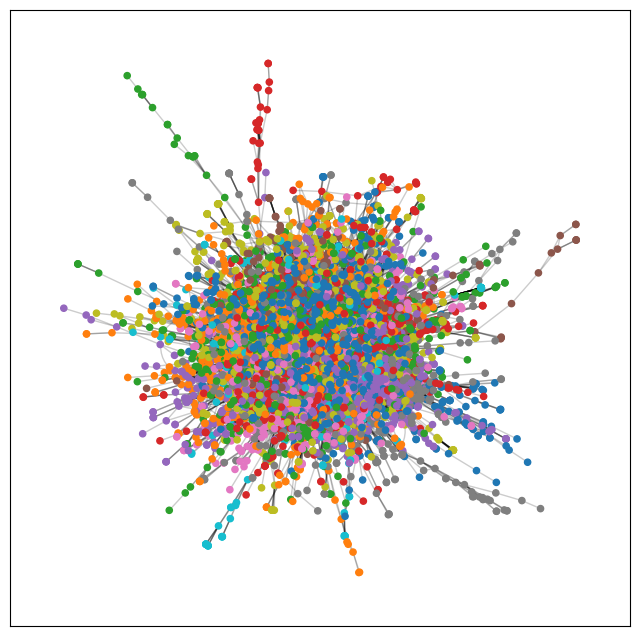

In [31]:
# Largest connected component
Gcc = G.subgraph(max(nx.connected_components(G), key=len))
pos = nx.spring_layout(Gcc, seed=42)

partition_c = community_louvain.best_partition(Gcc)

colors = [partition_c[node] for node in Gcc.nodes()]

plt.figure(figsize=(8,8))
nx.draw_networkx_nodes(Gcc, pos, node_color=colors, cmap=plt.cm.tab10, node_size=20)
nx.draw_networkx_edges(Gcc, pos, alpha=0.2)
plt.show()

In [32]:
#Greedy modularity communities (Unbounded)
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))
print("Greedy communities:", len(communities))

Greedy communities: 545


In [33]:
modularity_greedy = nx.algorithms.community.modularity(G, communities)
print("Greedy modularity:", modularity_greedy)

Greedy modularity: 0.7246831668638961


In [34]:
# Spectral clustering (Bounded)
from sklearn.cluster import SpectralClustering

A = nx.to_numpy_array(G)

sc = SpectralClustering(n_clusters=5, affinity='precomputed')
labels = sc.fit_predict(A)

print("Fixed k = 478 communities")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Fixed k = 478 communities


In [35]:
#Spectral clustering + K-means (Bounded)
from sklearn.cluster import KMeans
from scipy.sparse.linalg import eigsh

# Compute normalized Laplacian
L = nx.normalized_laplacian_matrix(Gcc)

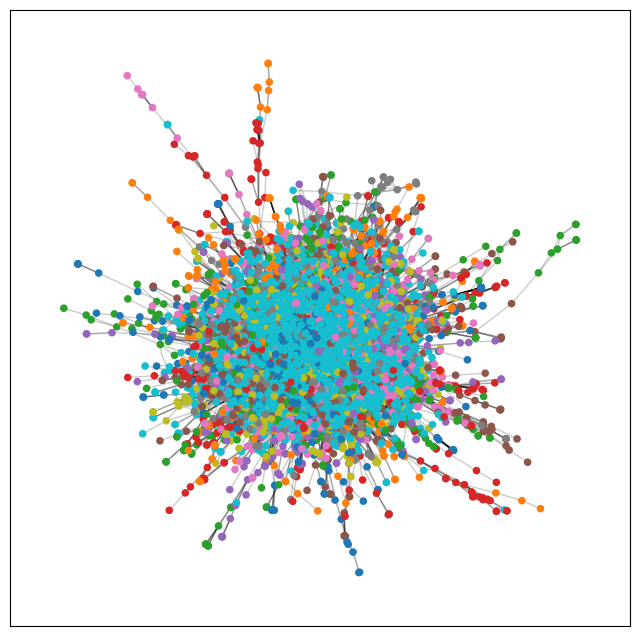

In [36]:
k = 478 # Number of clusters to partition into

eigenvalues, eigenvectors = eigsh(L, k=k, which='SM')

kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(eigenvectors)

node_list = list(Gcc.nodes())
community_map = {node_list[i]: labels[i] for i in range(len(node_list))}

colors = [community_map[node] for node in Gcc.nodes()]

plt.figure(figsize=(8,8))
nx.draw_networkx_nodes(Gcc, pos, node_color=colors, cmap=plt.cm.tab10, node_size=20)
nx.draw_networkx_edges(Gcc, pos, alpha=0.2)
plt.show()

Community Analysis

In [37]:
from collections import defaultdict

communities = defaultdict(list)

for node, comm in partition_c.items():
    communities[comm].append(node)

# Sort communities by size
sorted_comms = sorted(communities.items(), key=lambda x: len(x[1]), reverse=True)

# Largest community
largest_comm_id, largest_nodes = sorted_comms[0]

print("Largest community size:", len(largest_nodes))

Largest community size: 820


In [38]:
# Get degrees restricted to largest community
subG = Gcc.subgraph(largest_nodes)

top5 = sorted(subG.degree(), key=lambda x: x[1], reverse=True)[:5]
print(top5)

[('63113', 51), ('59077', 48), ('30160', 41), ('40517', 40), ('54785', 39)]


In [39]:
nx.density(subG)

0.008222400905327734

In [40]:
nx.average_clustering(subG)

0.4084873050353065

In [41]:
internal_edges = subG.number_of_edges()

cut_edges = 0
for node in largest_nodes:
    for neighbor in Gcc.neighbors(node):
        if neighbor not in largest_nodes:
            cut_edges += 1

print("Internal edges:", internal_edges)
print("External edges:", cut_edges)

Internal edges: 2761
External edges: 1623


In [42]:
nx.write_gexf(G, "collaboration.gexf")

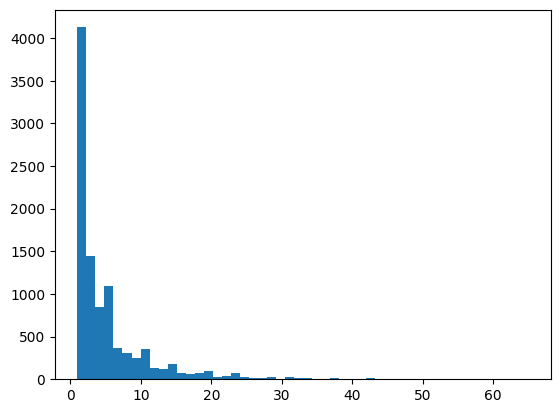

In [43]:
import matplotlib.pyplot as plt
import collections

degrees = [d for n, d in G.degree()]
plt.hist(degrees, bins=50)
plt.show()

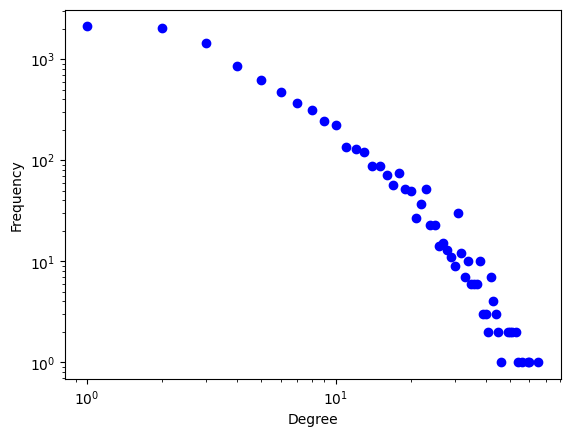

In [44]:
degree_count = collections.Counter(degrees)
deg, cnt = zip(*degree_count.items())

plt.loglog(deg, cnt, 'bo')
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

In [45]:
# Diameter and average shortest path length
# NOTE: changed G into Gcc

print("Diameter:", nx.diameter(Gcc))
print("Average shortest path:", nx.average_shortest_path_length(Gcc))

Diameter: 18
Average shortest path: 5.945432380163172


Comparison to Barabasi-Albert, Watts-Strogatz and Erd¨os-Renyi graphs

In [46]:
#Watts-Strogatz small-world model
n = Gcc.number_of_nodes()
avg_degree = sum(dict(Gcc.degree()).values()) / n

k = int(avg_degree)  # nearest even number
p = 0.1              # typical small-world rewiring

WS = nx.watts_strogatz_graph(n, k, p)

In [47]:
print("Collaboration clustering:", nx.average_clustering(Gcc))
print("WS clustering:", nx.average_clustering(WS))

print("Collaboration avg path:", nx.average_shortest_path_length(Gcc))
print("WS avg path:", nx.average_shortest_path_length(WS))

Collaboration clustering: 0.4815641520261653
WS clustering: 0.3718541549520943
Collaboration avg path: 5.945432380163172
WS avg path: 12.256148728032818


In [48]:
#Barabási-Albert preferential attachment model
m_real = Gcc.number_of_edges() 
print("Nodes:", n)
print("Edges:", m_real)
print("Avg degree:", avg_degree)

m = int(avg_degree / 2)
BA = nx.barabasi_albert_graph(n, m)

Nodes: 8638
Edges: 24827
Avg degree: 5.748321370687659


In [49]:
# Erdos-Rényi random graph
p = (2 * m_real) / (n * (n - 1))
ER = nx.erdos_renyi_graph(n, p)

In [50]:
def graph_stats(G):
    return {
        "avg_clustering": nx.average_clustering(G),
        "avg_path_length": nx.average_shortest_path_length(G),
        "diameter": nx.diameter(G),
        "density": nx.density(G)
    }

print("Collaboration:", graph_stats(Gcc))
print("BA:", graph_stats(BA))
# print("ER:", graph_stats(ER))


Collaboration: {'avg_clustering': 0.4815641520261653, 'avg_path_length': 5.945432380163172, 'diameter': 18, 'density': 0.0006655460658431931}
BA: {'avg_clustering': 0.005234461266813717, 'avg_path_length': 4.9513093821997005, 'diameter': 9, 'density': 0.00046301654042951756}


In [51]:
# Get largest connected component
Gcc = max(nx.connected_components(ER), key=len)
G_lcc = ER.subgraph(Gcc).copy()

# Then compute stats
print("ER:", graph_stats(G_lcc))

ER: {'avg_clustering': 0.0006265606811610529, 'avg_path_length': 5.35548400022805, 'diameter': 11, 'density': 0.0006754573846912019}


In [52]:
print("WS:", graph_stats(WS))
print("WS nodes:", WS.number_of_nodes())

WS: {'avg_clustering': 0.3718541549520943, 'avg_path_length': 12.256148728032818, 'diameter': 23, 'density': 0.0004631237698274864}
WS nodes: 8638


In [53]:
print("WS edges:", WS.number_of_edges())

WS edges: 17276


In [54]:
all_degrees = [d for n, d in WS.degree()]

# 2. Calculate the average degree
# The average degree is the sum of all degrees divided by the number of nodes (or 2 * num_edges / num_nodes).
avg_degree = sum(all_degrees) / len(WS.nodes)

print("WS average degree:", avg_degree)

WS average degree: 4.0


In [55]:
print("ER nodes:", ER.number_of_nodes())
print("ER edges:", ER.number_of_edges())
all_degrees = [d for n, d in ER.degree()]

# 2. Calculate the average degree
# The average degree is the sum of all degrees divided by the number of nodes (or 2 * num_edges / num_nodes).
avg_degree = sum(all_degrees) / len(ER.nodes)

print("ER average degree:", avg_degree)

ER nodes: 8638
ER edges: 25022
ER average degree: 5.793470710812688


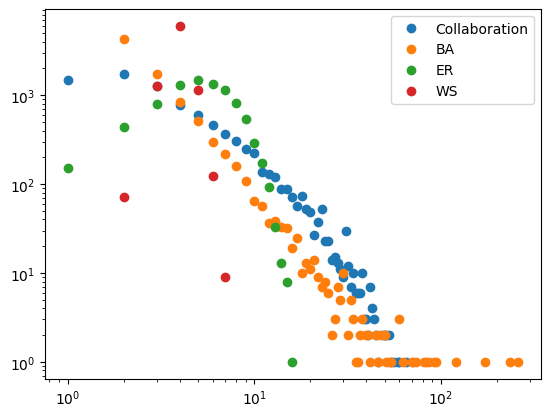

In [56]:
def plot_degree_distribution(G, label):
    degrees = [d for n, d in G.degree()]
    degree_count = collections.Counter(degrees)
    deg, cnt = zip(*sorted(degree_count.items()))
    plt.loglog(deg, cnt, marker='o', linestyle='', label=label)

# Note: changed the ER graph to G_lcc
Gcc_nodes = max(nx.connected_components(G), key=len)
Gcc = G.subgraph(Gcc_nodes).copy()

plt.figure()
plot_degree_distribution(Gcc, "Collaboration")
plot_degree_distribution(BA, "BA")
ER = G_lcc
plot_degree_distribution(ER, "ER")
plot_degree_distribution(WS, "WS")
plt.legend()
plt.show()

In [57]:
partition_ba = community_louvain.best_partition(BA)
partition_er = community_louvain.best_partition(ER)
partition_ws = community_louvain.best_partition(WS)

print("BA communities:", len(set(partition_ba.values())))
print("ER communities:", len(set(partition_er.values())))
print("WS communities:", len(set(partition_ws.values())))

BA communities: 39
ER communities: 28
WS communities: 98


In [58]:

degrees = np.array([d for n, d in G.degree()])

max_degree = degrees.max()
var_degree = degrees.var()
std_degree = degrees.std()

print("\nDegree heterogeneity")
print("1. Max degree =", max_degree)
print("2. Variance of degree =", var_degree)
print("3. Std of degree =", std_degree)


Degree heterogeneity
1. Max degree = 65
2. Variance of degree = 38.32788138438872
3. Std of degree = 6.190951573416539


In [59]:
# -----------------------------
# 3. Degree assortativity
# -----------------------------
assortativity = nx.degree_assortativity_coefficient(G)

print("\nAssortativity")
print("4. Degree assortativity coefficient =", assortativity)



Assortativity
4. Degree assortativity coefficient = 0.2675263505048915


In [70]:
# -----------------------------
# 4. Small-world coefficient (sigma)
# -----------------------------
# Use the largest connected component

# clustering coefficient
C = nx.average_clustering(Gcc)

# average shortest path length
L = nx.average_shortest_path_length(Gcc)

# random graph with same nodes/edges
n = Gcc.number_of_nodes()
m = Gcc.number_of_edges()

Gr = nx.gnm_random_graph(n, m)

Cr = nx.average_clustering(Gr)
largest_cc = max(nx.connected_components(Gr), key=len)
Gr_lcc = Gr.subgraph(largest_cc).copy()
Lr = nx.average_shortest_path_length(Gr_lcc)

sigma = (C / Cr) / (L / Lr)
a = C / Cr
b = L / Lr

print("\nSmall-world coefficient")
print("5. sigma =", sigma)




Small-world coefficient
5. sigma = 621.6473656360176


In [ ]:
import networkx as nx
import numpy as np
import random


def approximate_avg_path_length(G, sample_size=100):
    nodes = list(G.nodes())
    sample_nodes = random.sample(nodes, sample_size)

    path_lengths = []

    for node in sample_nodes:
        lengths = nx.single_source_shortest_path_length(G, node)
        path_lengths.extend(lengths.values())

    return np.mean(path_lengths)

# real network
C = nx.average_clustering(Gcc)
L = approximate_avg_path_length(Gcc)

n = Gcc.number_of_nodes()
m = Gcc.number_of_edges()

Cr_list = []
Lr_list = []

for _ in range(20):   # only 10 random graphs
    Gr = nx.gnm_random_graph(n, m)

    Cr_list.append(nx.average_clustering(Gr))

    largest_cc = max(nx.connected_components(Gr), key=len)
    Gr_lcc = Gr.subgraph(largest_cc).copy()

    Lr_list.append(approximate_avg_path_length(Gr_lcc))

Cr = np.mean(Cr_list)
Lr = np.mean(Lr_list)

sigma = (C / Cr) / (L / Lr)

print("sigma =", sigma)

sigma = 715.1307590466146


In [71]:
G.remove_edges_from(nx.selfloop_edges(G))
core_numbers = nx.core_number(G)

kmax = max(core_numbers.values())
kmax_nodes = [n for n, k in core_numbers.items() if k == kmax]

print("\nCore structure")
print("6. Max k-core value =", kmax)
print("7. Number of nodes in kmax-core =", len(kmax_nodes))


Core structure
6. Max k-core value = 31
7. Number of nodes in kmax-core = 32
